<a href="https://colab.research.google.com/github/SofiaDomeli/Neural_Network_HS/blob/adult/RedesNeurais_Adult.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> 🧠 Rede Neural 🧠 </center>

### 1. Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from tensorflow.keras.initializers import GlorotUniform # type: ignore

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

### 2. Variáveis e Ambiente

In [2]:
df = pd.read_csv('adults.csv')

atributos = df.drop(columns=['renda'], axis=1)
resposta = np.array(df['renda'])

df

,idade,classe-de-trabalho,carac-demografica,educacao,educacao-num,estado-civil,ocupacao,relacionamento,raca,sexo,ganho-capital,perda-capital,horas-por-semana,pais-nativo,renda
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


### Pré-processamento

In [3]:
# Resposta
label_encoder = LabelEncoder()

# Atributos
preprocessador = ColumnTransformer(
    transformers=[
        ('categoricas', OrdinalEncoder(), make_column_selector(dtype_include=['object', 'bool'])),
    ],
    remainder='passthrough', # Preserva as colunas que não foram transformadas
    verbose_feature_names_out = False
)

In [4]:
atributos = pd.DataFrame(data=preprocessador.fit_transform(atributos), columns=preprocessador.get_feature_names_out())
resposta = label_encoder.fit_transform(resposta)

#### 3.1 Divisão treino e teste

In [5]:
atributos_treino, atributos_teste, resposta_treino, resposta_teste = train_test_split(atributos, resposta, test_size=0.2, random_state=42)

### 4. Implementação - Hidden Layers

In [6]:
# modelo sequencial: 2 neurônios na oculta, 1 na saída
model = Sequential()
model.add(Dense(2, input_dim=len(atributos.columns), activation='sigmoid',
                kernel_initializer=GlorotUniform(seed=42)))
model.add(Dense(1, activation='sigmoid',
                kernel_initializer=GlorotUniform(seed=42)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# compile - 'contrato de treino'
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### 5. Treino do modelo

In [8]:
# treinamento com armazenamneto do historico
history = model.fit(atributos_treino, resposta_treino, epochs=100, verbose=0)

# predicoes
print("\nSaídas previstas:")
print(model.predict(atributos_teste).round())


Saídas previstas:
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]


### 6. Avaliação do modelo

In [9]:
# avaliacao final
loss, accuracy = model.evaluate(atributos_teste, resposta_teste, verbose=0)
print(f'\n--> Avaliação final no conjunto de treino')
print(f'Loss final: {loss:.2f}')
print(f'Acúracia final: {accuracy:.2f}')

# historico
print(f'\nNúmero de épocas treinadas: {len(history.history["loss"])}')
print(f'Último loss registrado: {history.history["loss"][-1]:.4f}')
print(f'Últimaa acurácia registrada: {history.history["accuracy"][-1]:.4f}')


--> Avaliação final no conjunto de treino
Loss final: 0.55
Acúracia final: 0.76

Número de épocas treinadas: 100
Último loss registrado: 0.5519
Últimaa acurácia registrada: 0.7593


#### 6.1 Gráfico de Avalição [ Em Desenvolvimento ]

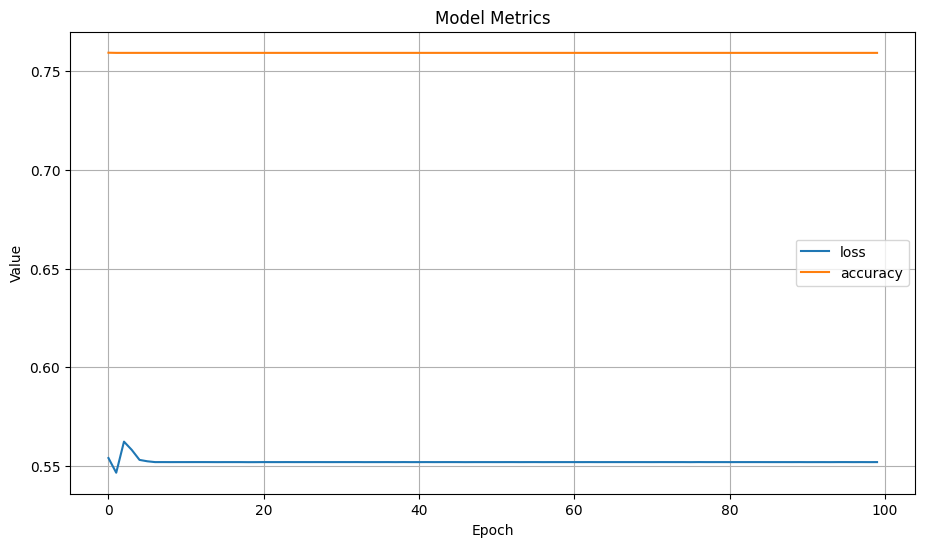

In [10]:
plt.figure(figsize=(24, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['accuracy'], label='accuracy')
plt.title('Model Metrics')
plt.ylabel('Value')
plt.xlabel('Epoch')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from itertools import product

def criar_modelo(neuronios=2, camadas=1, ativacao="sigmoid", otimizador="adam"):
    model = Sequential()
    # primeira camada oculta
    model.add(Dense(neuronios, input_dim=atributos_treino.shape[1],
                    activation=ativacao, kernel_initializer=GlorotUniform(seed=42)))
    # camadas adicionais
    for _ in range(camadas - 1):
        model.add(Dense(neuronios, activation=ativacao,
                        kernel_initializer=GlorotUniform(seed=42)))
    # saída
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer=otimizador, loss="binary_crossentropy", metrics=["accuracy"])
    return model


param_grid = {
    "neuronios": [2, 4, 8, 16, 32],
    "camadas": [1, 2, 3],
    "ativacao": ["sigmoid", "relu", "tanh"],
    "otimizador": ["adam", "sgd"],
    "epochs": [100]
}

melhor_acc = 0
melhores_params = None
historico_resultados = []

for valores in product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), valores))

    model = criar_modelo(
        neuronios=params["neuronios"],
        camadas=params["camadas"],
        ativacao=params["ativacao"],
        otimizador=params["otimizador"]
    )

    history = model.fit(
        atributos_treino, resposta_treino,
        epochs=100,
        verbose=0
    )

    loss, acc = model.evaluate(atributos_teste, resposta_teste, verbose=0)

    historico_resultados.append((params, acc))

    if acc > melhor_acc:
        melhor_acc = acc
        melhores_params = params

    print(f"Testado: {params} -> Acurácia teste: {acc:.4f}")

print("\nMelhores parâmetros encontrados:")
print(melhores_params)
print(f"Acurácia no teste: {melhor_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 1, 'ativacao': 'sigmoid', 'otimizador': 'adam', 'epochs': 100} -> Acurácia teste: 0.7588


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 1, 'ativacao': 'sigmoid', 'otimizador': 'sgd', 'epochs': 100} -> Acurácia teste: 0.7588


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 3, 'ativacao': 'relu', 'otimizador': 'sgd', 'epochs': 100} -> Acurácia teste: 0.7588


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 3, 'ativacao': 'tanh', 'otimizador': 'adam', 'epochs': 100} -> Acurácia teste: 0.7591


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
